# Signac 入门教程：PBMC scATAC-seq 基础分析流程

参考教程：https://stuartlab.org/signac/articles/pbmc_vignette.html

这份 Notebook 面向刚开始学习 scATAC-seq 的同学。我们使用 10x Genomics PBMC scATAC-seq 数据，按 Signac 官方教程改写为更适合课堂练习的流程：

1. 下载并认识 CellRanger ATAC 输出文件。
2. 创建 `ChromatinAssay` 和 Seurat 对象。
3. 添加基因注释和基础 QC。
4. 用 TF-IDF + LSI + UMAP 聚类。
5. 生成 gene activity，辅助注释细胞类型。
6. 做简单的差异开放峰和基因区域可视化。

注意：完整 PBMC 数据和 fragment 文件较大，第一次运行会比较慢。

## 0. 环境准备

建议使用 R kernel。需要的主要包：

- `Signac`
- `Seurat`
- `GenomicRanges`
- `GenomeInfoDb`
- `AnnotationHub`
- `ggplot2`
- `patchwork`

如果包还没有安装，请优先让服务器管理员在统一 R 环境中安装，避免每位同学重复编译。

In [1]:
library(Signac)
library(Seurat)
library(GenomicRanges)
library(GenomeInfoDb)
library(AnnotationHub)
library(ggplot2)
library(patchwork)
library(EnsDb.Hsapiens.v86)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following 

## 1. 下载数据

Signac 官方 PBMC 教程使用 10x Genomics 的 scATAC-seq 数据。这个数据集需要 4 个文件：

- peak/cell 矩阵 H5 文件。
- 单细胞 metadata CSV。
- fragments 文件。
- fragments 索引 `.tbi` 文件。

下面代码只负责生成下载命令。建议在服务器 shell 中运行，或者取消 R 代码里的注释后用 `system()` 下载。

In [2]:
DATA_DIR <- "/home/huajiao/HJcodex/tutorial/data/signac_pbmc"
dir.create(DATA_DIR, recursive = TRUE, showWarnings = FALSE)

base_url <- "https://cf.10xgenomics.com/samples/cell-atac/2.1.0/10k_pbmc_ATACv2_nextgem_Chromium_Controller"
files <- c(
  "10k_pbmc_ATACv2_nextgem_Chromium_Controller_filtered_peak_bc_matrix.h5",
  "10k_pbmc_ATACv2_nextgem_Chromium_Controller_singlecell.csv",
  "10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz",
  "10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz.tbi"
)

download_cmd <- paste(
  "wget -c -P", shQuote(DATA_DIR),
  paste0(base_url, "/", files)
)
cat(paste(download_cmd, collapse = "\n"))

# 如果服务器允许在 R 里调用 shell，可以取消下面这一行注释：
# invisible(lapply(download_cmd, system))

wget -c -P '/home/huajiao/HJcodex/tutorial/data/signac_pbmc' https://cf.10xgenomics.com/samples/cell-atac/2.1.0/10k_pbmc_ATACv2_nextgem_Chromium_Controller/10k_pbmc_ATACv2_nextgem_Chromium_Controller_filtered_peak_bc_matrix.h5
wget -c -P '/home/huajiao/HJcodex/tutorial/data/signac_pbmc' https://cf.10xgenomics.com/samples/cell-atac/2.1.0/10k_pbmc_ATACv2_nextgem_Chromium_Controller/10k_pbmc_ATACv2_nextgem_Chromium_Controller_singlecell.csv
wget -c -P '/home/huajiao/HJcodex/tutorial/data/signac_pbmc' https://cf.10xgenomics.com/samples/cell-atac/2.1.0/10k_pbmc_ATACv2_nextgem_Chromium_Controller/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz
wget -c -P '/home/huajiao/HJcodex/tutorial/data/signac_pbmc' https://cf.10xgenomics.com/samples/cell-atac/2.1.0/10k_pbmc_ATACv2_nextgem_Chromium_Controller/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz.tbi

## 2. 创建 ChromatinAssay 和 Seurat 对象

scATAC-seq 的 count matrix 和 scRNA-seq 类似，但行不是基因，而是 peak 区域。Signac 用 `ChromatinAssay` 保存 peaks、fragment 文件路径、基因组注释、motif 等信息。

这里的 `min.cells = 10` 和 `min.features = 200` 是建对象时的初步过滤，不等于最终 QC。

In [3]:
h5_file <- file.path(DATA_DIR, "10k_pbmc_ATACv2_nextgem_Chromium_Controller_filtered_peak_bc_matrix.h5")
meta_file <- file.path(DATA_DIR, "10k_pbmc_ATACv2_nextgem_Chromium_Controller_singlecell.csv")
frag_file <- file.path(DATA_DIR, "10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz")

stopifnot(file.exists(h5_file), file.exists(meta_file), file.exists(frag_file))

counts <- Read10X_h5(filename = h5_file)
metadata <- read.csv(file = meta_file, header = TRUE, row.names = 1)

chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c(":", "-"),
  fragments = frag_file,
  min.cells = 10,
  min.features = 200
)

pbmc <- CreateSeuratObject(
  counts = chrom_assay,
  assay = "peaks",
  meta.data = metadata
)

pbmc
pbmc[["peaks"]]

Computing hash



An object of class Seurat 
165434 features across 10246 samples within 1 assay 
Active assay: peaks (165434 features, 0 variable features)
 2 layers present: counts, data

ChromatinAssay data with 165434 features for 10246 cells
Variable features: 0 
Genome: 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 1 

## 3. 只保留标准染色体，并添加基因注释

10x 数据里可能包含 scaffold contig。入门分析一般先保留标准染色体。

In [4]:
peaks.keep <- seqnames(granges(pbmc)) %in% standardChromosomes(granges(pbmc))
pbmc <- pbmc[as.vector(peaks.keep), ]
library(AnnotationHub)
ah <- AnnotationHub()

annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevels(annotations) <- paste0("chr", seqlevels(annotations))
genome(annotations) <- "hg38"

Annotation(pbmc) <- annotations
pbmc[["peaks"]]

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

ChromatinAssay data with 165376 features for 10246 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: FALSE 
Fragment files: 1 

## 4. 计算 QC 指标

scATAC-seq 常看的 QC 指标包括：

- `nCount_peaks`：落在 peaks 中的总 fragment 数。
- `pct_reads_in_peaks`：FRiP 类指标，越低通常说明信号质量差。
- `blacklist_ratio`：落在 ENCODE blacklist 区域的比例，越高越可疑。
- `nucleosome_signal`：核小体信号，过高可能代表低质量细胞。
- `TSS.enrichment`：TSS 富集，越高通常说明 ATAC 信号更集中在调控区域。

阈值没有放之四海皆准的固定值；下面采用官方教程的 PBMC 示例阈值。

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

loading from cache



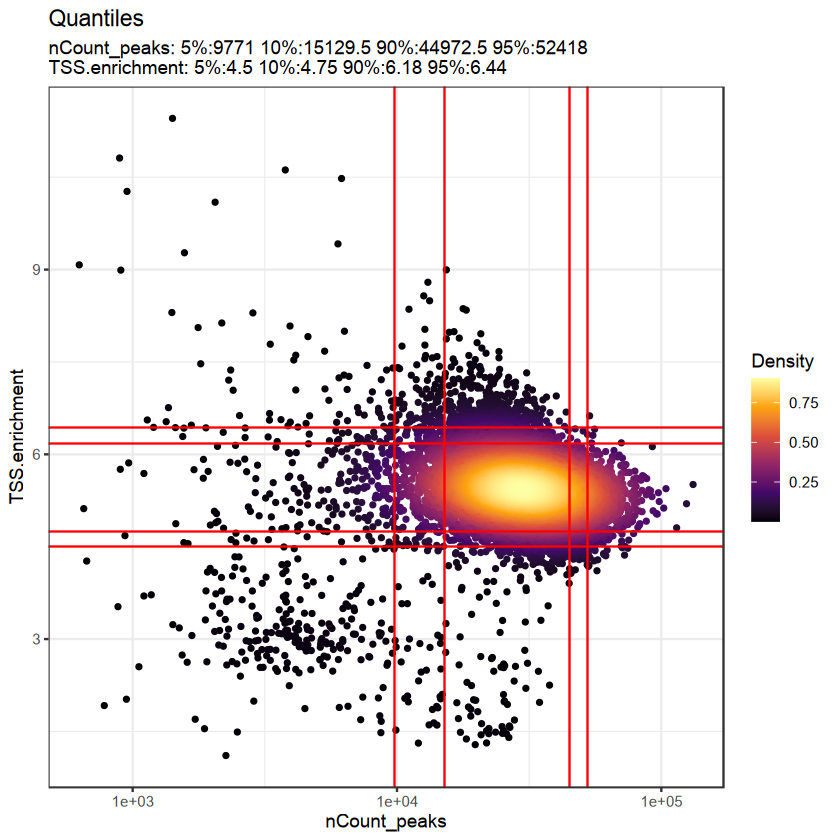

In [5]:
pbmc <- NucleosomeSignal(object = pbmc)
pbmc <- TSSEnrichment(object = pbmc)

pbmc$pct_reads_in_peaks <- pbmc$peak_region_fragments / pbmc$passed_filters * 100

blacklist_regions <- ah[["AH107305"]]
pbmc$blacklist_ratio <- FractionCountsInRegion(
  object = pbmc,
  assay = "peaks",
  regions = blacklist_regions
)

DensityScatter(pbmc, x = "nCount_peaks", y = "TSS.enrichment", log_x = TRUE, quantiles = TRUE)

Warning message:
"Removed 63 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_bar()`)."


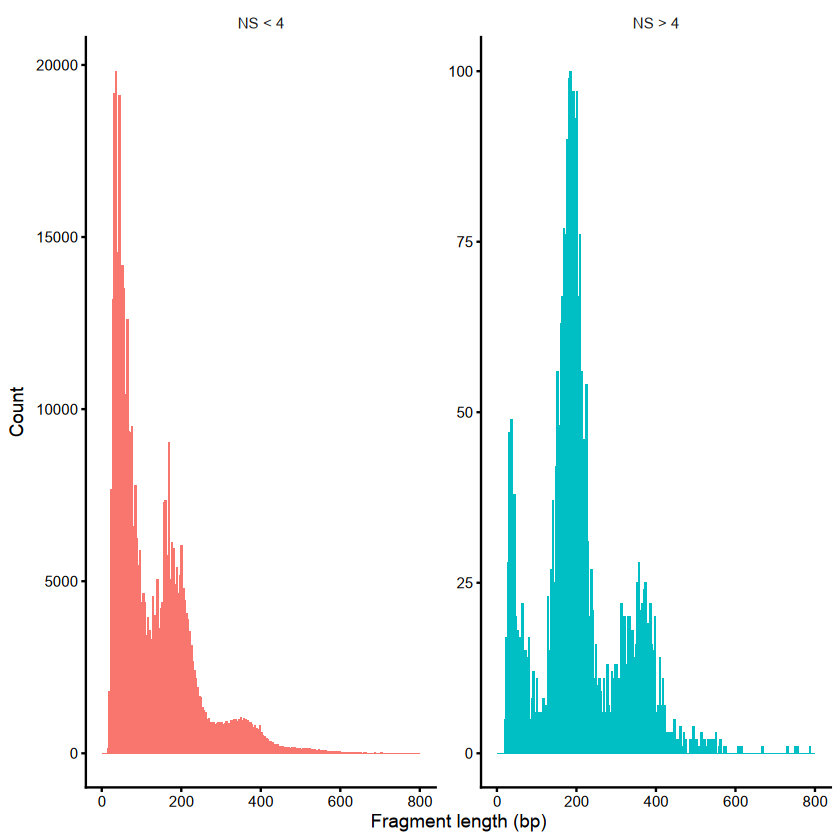

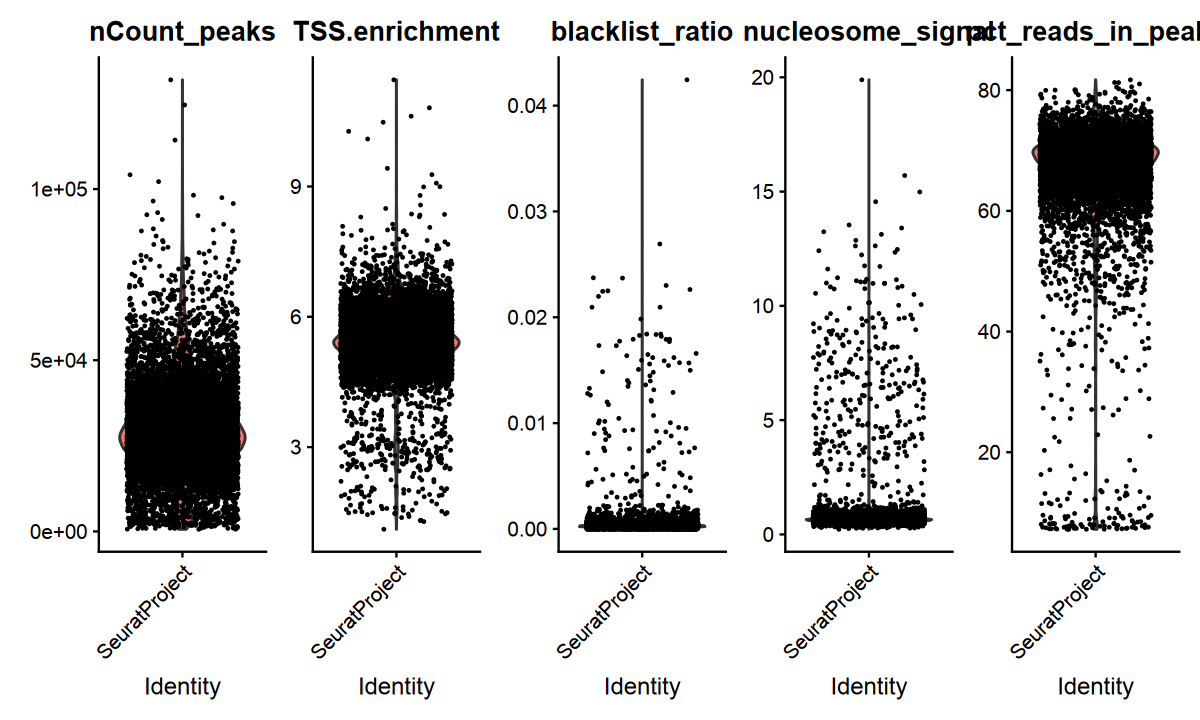

In [6]:
pbmc$nucleosome_group <- ifelse(pbmc$nucleosome_signal > 4, "NS > 4", "NS < 4")
FragmentHistogram(object = pbmc, group.by = "nucleosome_group")
options(repr.plot.width=10, repr.plot.height=6)
VlnPlot(
  object = pbmc,
  features = c(
    "nCount_peaks",
    "TSS.enrichment",
    "blacklist_ratio",
    "nucleosome_signal",
    "pct_reads_in_peaks"
  ),
  pt.size = 0.1,
  ncol = 5
)

In [7]:
pbmc <- subset(
  x = pbmc,
  subset = nCount_peaks > 9000 &
    nCount_peaks < 100000 &
    pct_reads_in_peaks > 40 &
    blacklist_ratio < 0.01 &
    nucleosome_signal < 4 &
    TSS.enrichment > 4
)

pbmc

An object of class Seurat 
165376 features across 9649 samples within 1 assay 
Active assay: peaks (165376 features, 0 variable features)
 2 layers present: counts, data

## 5. TF-IDF、LSI、UMAP 和聚类

scATAC-seq 数据非常稀疏，Signac 的常规降维流程是：

1. `RunTFIDF()`：对 peak/cell 矩阵做 TF-IDF 标准化。
2. `FindTopFeatures()`：选择用于降维的 peaks。
3. `RunSVD()`：得到 LSI 低维表示。
4. `RunUMAP()`、`FindNeighbors()`、`FindClusters()`：使用 Seurat 的图聚类和可视化。

第一维 LSI 常常和测序深度强相关，所以通常从 `dims = 2:30` 开始。

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



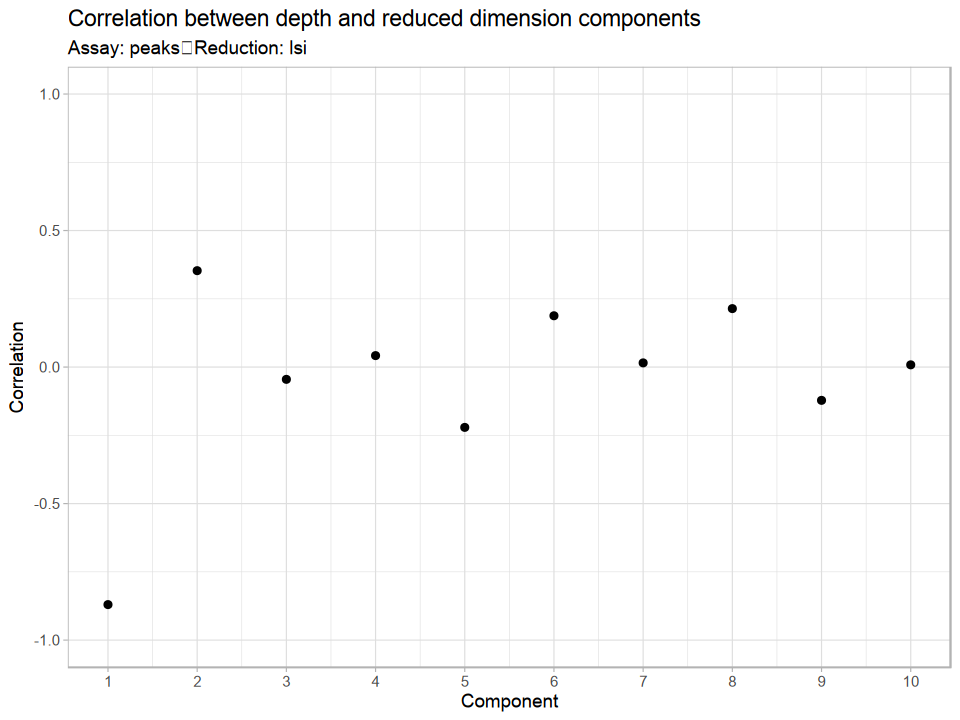

In [8]:
pbmc <- RunTFIDF(pbmc)
pbmc <- FindTopFeatures(pbmc, min.cutoff = "q0")
pbmc <- RunSVD(pbmc)
options(repr.plot.width=8, repr.plot.height=6)

DepthCor(pbmc)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
19:56:15 UMAP embedding parameters a = 0.9922 b = 1.112

19:56:15 Read 9649 rows and found 29 numeric columns

19:56:15 Using Annoy for neighbor search, n_neighbors = 30

19:56:15 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:56:15 Writing NN index file to temp file /tmp/RtmpDtku6z/file3014925067ae8a

19:56:15 Searching Annoy index using 1 thread, search_k = 3000

19:56:17 Annoy recall = 100%

19:56:19 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

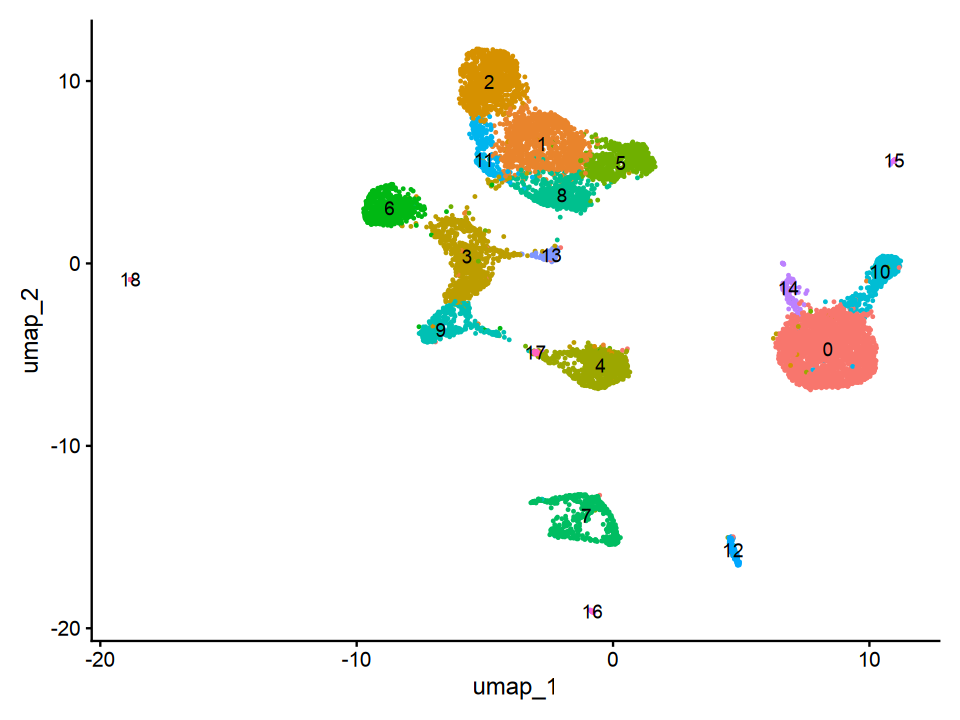

In [9]:
pbmc <- RunUMAP(object = pbmc, reduction = "lsi", dims = 2:30)
pbmc <- FindNeighbors(object = pbmc, reduction = "lsi", dims = 2:30)
pbmc <- FindClusters(object = pbmc, verbose = FALSE, algorithm = 3)

DimPlot(object = pbmc, label = TRUE) + NoLegend()

## 6. Gene activity：用基因活性辅助细胞类型注释

scATAC-seq 不能直接测表达量，但可以把 gene body 和 promoter 附近的开放信号汇总成 gene activity。它比 RNA 表达更稀疏、更粗糙，但对初步识别 PBMC 细胞类型很有帮助。

常用 marker：

- B cell：`MS4A1`
- T cell：`CD3D`、`LEF1`
- NK cell：`NKG7`
- Monocyte：`LYZ`、`TREM1`

Extracting gene coordinates

Warning message in SingleFeatureMatrix(fragment = fragments[[x]], features = features, :
"13 features are on seqnames not present in the fragment file. These will be removed."
Extracting reads overlapping genomic regions



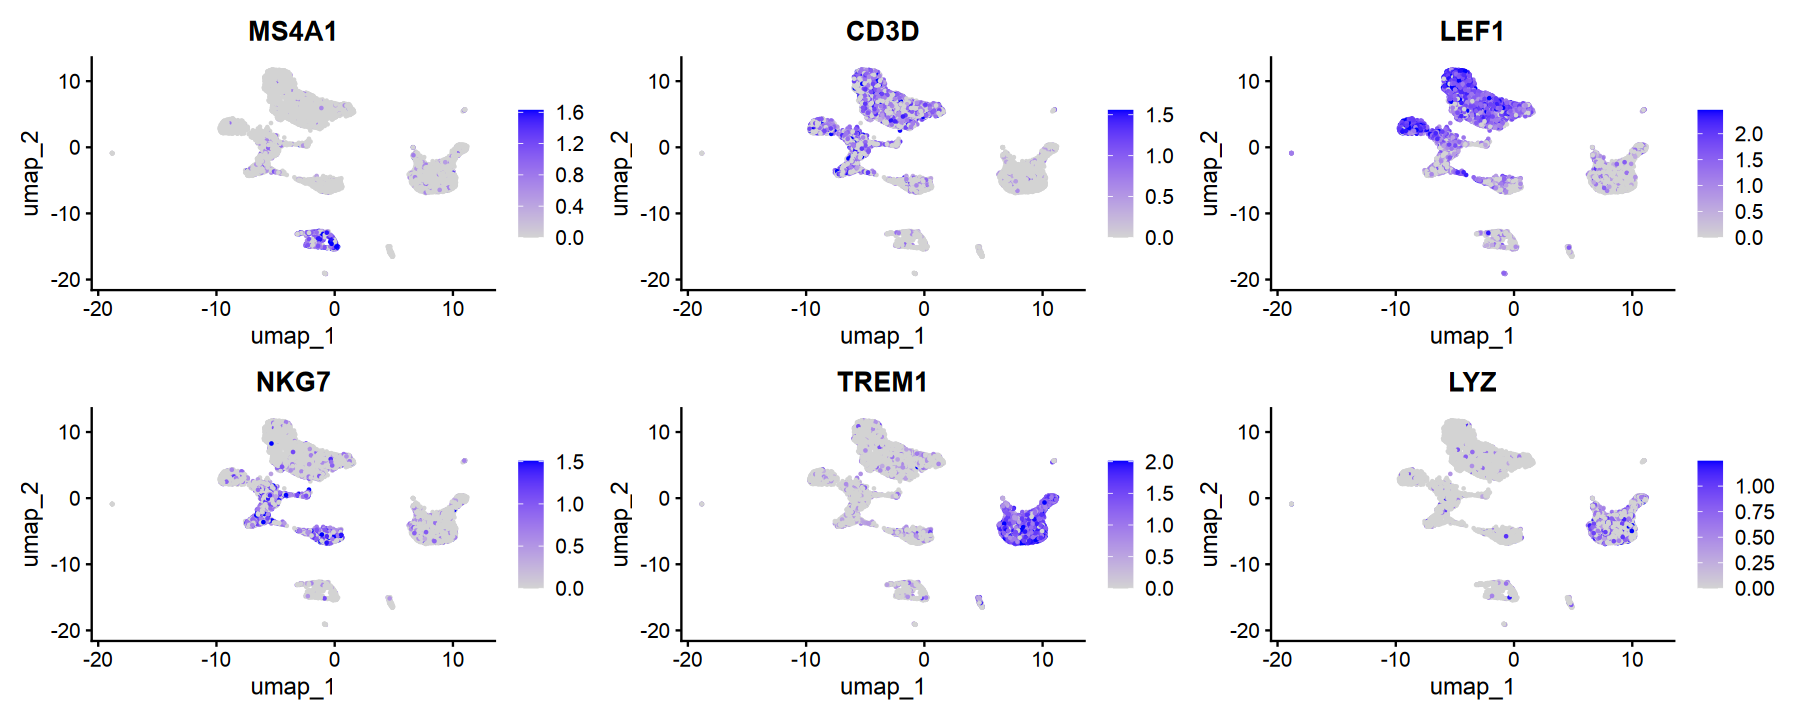

In [10]:
gene.activities <- GeneActivity(pbmc)

pbmc[["RNA"]] <- CreateAssayObject(counts = gene.activities)
pbmc <- NormalizeData(
  object = pbmc,
  assay = "RNA",
  normalization.method = "LogNormalize",
  scale.factor = median(pbmc$nCount_RNA)
)

DefaultAssay(pbmc) <- "RNA"
options(repr.plot.width=15, repr.plot.height=6)
FeaturePlot(
  object = pbmc,
  features = c("MS4A1", "CD3D", "LEF1", "NKG7", "TREM1", "LYZ"),
  pt.size = 0.1,
  max.cutoff = "q95",
  ncol = 3
)

## 7. 可选：用 scRNA-seq 参考数据做 label transfer

官方教程还使用同体系 PBMC scRNA-seq 数据给 scATAC 细胞转移标签。这个步骤会增加运行时间，但对初学者理解“ATAC 聚类如何注释”很有帮助。

如果你已经有 `pbmc_10k_v3.rds`，可以设置 `RNA_REF` 后运行下面代码。

In [11]:
RNA_REF <- file.path(DATA_DIR, "pbmc_10k_v3.rds")

if (file.exists(RNA_REF)) {
  pbmc_rna <- readRDS(RNA_REF)
  pbmc_rna <- UpdateSeuratObject(pbmc_rna)

  transfer.anchors <- FindTransferAnchors(
    reference = pbmc_rna,
    query = pbmc,
    reduction = "cca"
  )

  predicted.labels <- TransferData(
    anchorset = transfer.anchors,
    refdata = pbmc_rna$celltype,
    weight.reduction = pbmc[["lsi"]],
    dims = 2:30
  )

  pbmc <- AddMetaData(object = pbmc, metadata = predicted.labels)

  plot1 <- DimPlot(pbmc_rna, group.by = "celltype", label = TRUE, repel = TRUE) +
    NoLegend() +
    ggtitle("scRNA-seq")
  plot2 <- DimPlot(pbmc, group.by = "predicted.id", label = TRUE, repel = TRUE) +
    NoLegend() +
    ggtitle("scATAC-seq")

  plot1 + plot2
} else {
  message("未找到 RNA 参考对象，跳过 label transfer。")
}

未找到 RNA 参考对象，跳过 label transfer。



## 8. 差异 peaks

如果已经有 `predicted.id`，可以按预测细胞类型比较；否则可以按 Seurat 聚类比较。

下面以 CD4 naive T cell 和 CD14 monocyte 为例。`test.use = "LR"` 时加入 `latent.vars = "nCount_peaks"`，可以部分控制测序深度差异。

In [12]:
DefaultAssay(pbmc) <- "peaks"

if ("predicted.id" %in% colnames(pbmc@meta.data)) {
  Idents(pbmc) <- pbmc$predicted.id
} else {
  Idents(pbmc) <- "seurat_clusters"
}

table(Idents(pbmc))


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
2217 1173 1022  877  696  615  582  510  485  397  343  234  147  127  127   30 
  16   17   18 
  29   29    9 

In [13]:
if (all(c("CD4 Naive", "CD14+ Monocytes") %in% levels(Idents(pbmc)))) {
  da_peaks <- FindMarkers(
    object = pbmc,
    ident.1 = "CD4 Naive",
    ident.2 = "CD14+ Monocytes",
    test.use = "LR",
    latent.vars = "nCount_peaks",
    min.pct = 0.1
  )

  head(da_peaks)

  top_peak <- rownames(da_peaks)[1]
  VlnPlot(pbmc, features = top_peak, pt.size = 0.1, idents = c("CD4 Naive", "CD14+ Monocytes")) |
    FeaturePlot(pbmc, features = top_peak, pt.size = 0.1)
} else {
  message("当前对象没有 CD4 Naive / CD14+ Monocytes 标签。请先完成 label transfer，或把 ident.1/ident.2 换成聚类编号。")
}

当前对象没有 CD4 Naive / CD14+ Monocytes 标签。请先完成 label transfer，或把 ident.1/ident.2 换成聚类编号。



## 9. 把 peak 坐标连到附近基因，并画 genome coverage

peak 名字通常是 `chr-start-end`，不够直观。`ClosestFeature()` 可以找附近基因，`CoveragePlot()` 可以画某个基因附近的 pseudo-bulk ATAC 信号。

In [14]:
if (exists("da_peaks")) {
  open_cd4naive <- rownames(da_peaks[da_peaks$avg_log2FC > 3, ])
  open_cd14mono <- rownames(da_peaks[da_peaks$avg_log2FC < -3, ])

  closest_genes_cd4naive <- ClosestFeature(pbmc, regions = open_cd4naive)
  closest_genes_cd14mono <- ClosestFeature(pbmc, regions = open_cd14mono)

  head(closest_genes_cd4naive)
  head(closest_genes_cd14mono)
}

In [15]:
if (exists("open_cd4naive") && length(open_cd4naive) > 0) {
  pbmc <- SortIdents(pbmc)

  regions_highlight <- subsetByOverlaps(
    StringToGRanges(open_cd4naive),
    LookupGeneCoords(pbmc, "CD4")
  )

  CoveragePlot(
    object = pbmc,
    region = "CD4",
    region.highlight = regions_highlight,
    extend.upstream = 1000,
    extend.downstream = 1000
  )
}